# Homework 2: Phân loại Đa lớp với KNN, One-vs-Rest, và One-vs-One
## Môn học: Trí Tuệ Nhân Tạo - EE3063

Nhóm Thực Hiện: [Điền tên thành viên nhóm]

MSSV: [Điền MSSV thành viên nhóm]

Nội dung:
1. Giới thiệu bài toán phân loại đa lớp và tạo dữ liệu mẫu.
2. Xây dựng thuật toán K-Nearest Neighbors (KNN) từ đầu.
3. Xây dựng chiến lược One-vs-Rest (OvR) sử dụng Perceptron làm bộ phân loại cơ sở.
4. Xây dựng chiến lược One-vs-One (OvO) sử dụng Perceptron làm bộ phân loại cơ sở.
5. Áp dụng các thuật toán lên dữ liệu và đánh giá.

In [14]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter # Dùng để đếm số lần xuất hiện của các lớp trong KNN
from sklearn.model_selection import train_test_split # Dùng để chia dữ liệu
from sklearn.preprocessing import StandardScaler # Chuẩn hóa dữ liệu
from sklearn.datasets import make_blobs # Tạo dữ liệu mẫu có cụm


## 1. Giới thiệu

Bài toán phân loại đa lớp là một bài toán phổ biến trong học máy, nơi chúng ta cần gán một đối tượng vào một trong nhiều hơn hai lớp (categories). Ví dụ, nhận dạng chữ số (0-9), phân loại các loại hoa, v.v.

Trong bài tập này, chúng ta sẽ tự xây dựng và áp dụng ba phương pháp/thuật toán khác nhau để giải quyết bài toán phân loại đa lớp:
1.  **K-Nearest Neighbors (KNN):** Một thuật toán học có giám sát đơn giản, dựa trên việc tìm các điểm dữ liệu gần nhất.
2.  **One-vs-Rest (OvR) / One-vs-All (OvA):** Một chiến lược để sử dụng các bộ phân loại nhị phân (binary classifiers) cho bài toán đa lớp. Chúng ta sẽ sử dụng Perceptron (từ HW1) làm bộ phân loại nhị phân cơ sở.
3.  **One-vs-One (OvO):** Một chiến lược khác cũng sử dụng các bộ phân loại nhị phân cho bài toán đa lớp, cũng với Perceptron làm bộ phân loại cơ sở.

### Yêu cầu về Dataset (HW2)

Đề bài yêu cầu tự thu thập dataset bao gồm 3 lớp, ít nhất 3 thuộc tính.
Do mục đích minh họa thuật toán, trong notebook này, chúng ta sẽ tạo một bộ dữ liệu mẫu đơn giản gồm 3 lớp, mỗi lớp có 3 đặc trưng (features) bằng cách sử dụng hàm `make_blobs` từ `sklearn.datasets`.

In [15]:
# --- Tạo Dữ liệu Mẫu ---
# Tạo dữ liệu gồm 3 lớp, mỗi lớp có 3 đặc trưng, tổng cộng 150 mẫu.
# Các cụm sẽ có độ phân tán (cluster_std) nhất định để bài toán không quá dễ.
n_samples_total = 150
n_features = 3
n_classes = 3
centers = [(2, 2, 2), (8, 2, 5), (5, 8, 8)] # Vị trí trung tâm của 3 cụm (lớp)

X_data, y_data = make_blobs(n_samples=n_samples_total,
                            centers=centers,
                            n_features=n_features,
                            cluster_std=1.2, # Độ phân tán của các cụm
                            random_state=42)

# Chuẩn hóa dữ liệu (quan trọng cho KNN và Perceptron)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

# Chia dữ liệu thành tập huấn luyện và tập kiểm thử
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_data, test_size=0.3, random_state=42, stratify=y_data)

print(f"Kích thước tập huấn luyện X: {X_train.shape}, y: {y_train.shape}")
print(f"Kích thước tập kiểm thử X: {X_test.shape}, y: {y_test.shape}")
print(f"Các lớp trong dữ liệu: {np.unique(y_data)}")

Kích thước tập huấn luyện X: (105, 3), y: (105,)
Kích thước tập kiểm thử X: (45, 3), y: (45,)
Các lớp trong dữ liệu: [0 1 2]


## 2. K-Nearest Neighbors (KNN)

### 2.1. Giải thích Thuật toán

K-Nearest Neighbors (KNN) là một thuật toán học có giám sát thuộc loại "lazy learning" (học lười) hoặc "instance-based learning" (học dựa trên mẫu).

-   **Ý tưởng chính:** Để phân loại một điểm dữ liệu mới, KNN tìm kiếm $k$ điểm dữ liệu trong tập huấn luyện gần nhất với điểm đó (dựa trên một thước đo khoảng cách, thường là Euclidean). Sau đó, nhãn của điểm dữ liệu mới được quyết định dựa trên nhãn của $k$ láng giềng này (thường là lấy nhãn xuất hiện nhiều nhất - majority vote).

-   **Các bước thực hiện khi dự đoán cho một điểm mới $x_{new}$:**
    1.  Tính khoảng cách từ $x_{new}$ đến tất cả các điểm $x_i$ trong tập huấn luyện.
    2.  Sắp xếp các khoảng cách này theo thứ tự tăng dần và chọn ra $k$ điểm có khoảng cách nhỏ nhất (là $k$ láng giềng gần nhất).
    3.  Xác định nhãn của $k$ láng giềng này.
    4.  Gán nhãn cho $x_{new}$ là nhãn xuất hiện nhiều nhất trong số $k$ láng giềng. Nếu có nhiều hơn một nhãn cùng xuất hiện nhiều nhất, có thể chọn ngẫu nhiên hoặc dựa trên một quy tắc ưu tiên nào đó (ví dụ: láng giềng gần hơn có trọng số cao hơn, nhưng ở đây ta làm đơn giản là majority vote).

-   **Tham số quan trọng:**
    * $k$: Số lượng láng giềng. Việc chọn $k$ ảnh hưởng lớn đến kết quả.
        * $k$ nhỏ: Mô hình nhạy cảm với nhiễu, dễ bị overfitting.
        * $k$ lớn: Đường biên quyết định mượt hơn, ít nhạy cảm với nhiễu nhưng có thể làm mất đi các chi tiết cục bộ (underfitting).
    * Thước đo khoảng cách: Euclidean, Manhattan, Minkowski,... (Trong bài này ta dùng Euclidean).

-   **Ưu điểm:** Đơn giản, dễ hiểu, dễ triển khai, không cần giả định về phân phối dữ liệu.
-   **Nhược điểm:** Chi phí tính toán cao khi dự đoán (phải tính khoảng cách đến tất cả các điểm huấn luyện), cần chuẩn hóa dữ liệu, nhạy cảm với việc chọn $k$ và thước đo khoảng cách, "curse of dimensionality" (hiệu suất giảm khi số chiều dữ liệu lớn).

(Tham khảo slide: "K nearest neighbors.pdf")

Lớp KNN nhóm tự xây dựng

In [16]:
class KNNClassifier:
    def __init__(self, k=3):
        """
        Khởi tạo bộ phân loại KNN.
        Args:
            k (int): Số lượng láng giềng gần nhất.
        """
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X_train, y_train):
        """
        "Huấn luyện" mô hình KNN.
        Thực chất KNN là lazy learner, nên bước fit chỉ đơn giản là lưu trữ dữ liệu huấn luyện.
        Args:
            X_train (np.array): Ma trận đặc trưng huấn luyện.
            y_train (np.array): Vector nhãn huấn luyện.
        """
        self.X_train = X_train
        self.y_train = y_train

    def _euclidean_distance(self, x1, x2):
        """
        Tính khoảng cách Euclidean giữa hai điểm.
        Args:
            x1 (np.array): Điểm thứ nhất.
            x2 (np.array): Điểm thứ hai.
        Returns:
            float: Khoảng cách Euclidean.
        """
        return np.sqrt(np.sum((x1 - x2)**2))

    def predict_single(self, x_test):
        """
        Dự đoán nhãn cho một điểm dữ liệu kiểm thử.
        Args:
            x_test (np.array): Điểm dữ liệu kiểm thử.
        Returns:
            int: Nhãn dự đoán.
        """
        if self.X_train is None or self.y_train is None:
            raise ValueError("Mô hình KNN chưa được huấn luyện. Hãy gọi hàm fit() trước.")

        # 1. Tính khoảng cách từ x_test đến tất cả các điểm trong X_train
        distances = [self._euclidean_distance(x_test, x_train_point) for x_train_point in self.X_train]
        
        # 2. Sắp xếp và lấy k láng giềng gần nhất
        # Lấy chỉ số của k điểm gần nhất
        k_indices = np.argsort(distances)[:self.k]
        
        # 3. Lấy nhãn của k láng giềng này
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        
        # 4. Xác định nhãn xuất hiện nhiều nhất (majority vote)
        # Counter sẽ đếm số lần xuất hiện của mỗi nhãn
        # most_common(1) trả về một list chứa tuple (nhãn, số_lần_xuất_hiện) của nhãn phổ biến nhất
        most_common_label = Counter(k_nearest_labels).most_common(1)[0][0]
        return most_common_label

    def predict(self, X_test):
        """
        Dự đoán nhãn cho một tập các điểm dữ liệu kiểm thử.
        Args:
            X_test (np.array): Ma trận đặc trưng của dữ liệu kiểm thử.
        Returns:
            np.array: Vector các nhãn dự đoán.
        """
        predictions = [self.predict_single(x_test_point) for x_test_point in X_test]
        return np.array(predictions)

## 3. One-vs-Rest (OvR) / One-vs-All (OvA)

### 3.1. Giải thích Chiến lược

One-vs-Rest (OvR) là một chiến lược phổ biến để mở rộng các bộ phân loại nhị phân (chỉ phân biệt được 2 lớp) cho bài toán phân loại đa lớp.

-   **Ý tưởng chính:** Nếu có $N$ lớp, chúng ta sẽ huấn luyện $N$ bộ phân loại nhị phân riêng biệt. Mỗi bộ phân loại thứ $i$ ($classifier_i$) sẽ được huấn luyện để phân biệt các mẫu thuộc lớp $i$ (coi là lớp "dương") với tất cả các mẫu còn lại từ $N-1$ lớp khác (coi chung là lớp "âm").

-   **Quá trình huấn luyện (cho $N$ lớp):**
    1.  Với mỗi lớp $i$ (từ 0 đến $N-1$):
        a.  Tạo một tập dữ liệu nhị phân mới:
            * Các mẫu thuộc lớp $i$ được gán nhãn là 1 (dương).
            * Tất cả các mẫu không thuộc lớp $i$ được gán nhãn là 0 (âm).
        b.  Huấn luyện một bộ phân loại nhị phân ($classifier_i$) trên tập dữ liệu nhị phân này.

-   **Quá trình dự đoán cho một điểm mới $x_{new}$:**
    1.  Đưa $x_{new}$ qua tất cả $N$ bộ phân loại nhị phân đã huấn luyện.
    2.  Mỗi $classifier_i$ sẽ đưa ra một "điểm số" hoặc "xác suất" cho thấy $x_{new}$ có khả năng thuộc về lớp $i$.
    3.  Lớp cuối cùng được dự đoán cho $x_{new}$ là lớp mà bộ phân loại tương ứng đưa ra điểm số tự tin nhất (ví dụ: giá trị đầu ra lớn nhất từ hàm quyết định, hoặc xác suất cao nhất).

-   **Ưu điểm:** Tương đối đơn giản để triển khai, chỉ cần $N$ bộ phân loại.
-   **Nhược điểm:** Có thể gặp vấn đề mất cân bằng lớp khi huấn luyện từng bộ phân loại nhị phân (số mẫu "dương" ít hơn nhiều so với số mẫu "âm").

(Tham khảo slide: "Binary Classifier for Multi-class.pdf", trang 5-6)

Trong bài này, chúng ta sẽ sử dụng **Perceptron** (đã xây dựng ở HW1) làm bộ phân loại nhị phân cơ sở.

Giả sử lớp Perceptron đã được định nghĩa như trong HW1

In [17]:
class Perceptron: # Copy từ HW1, có thể cần điều chỉnh nhẹ
    def __init__(self, n_iters=100):
        self.n_iters = n_iters
        self.weights = None # Bao gồm cả bias w0

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features + 1)
        X_b = np.concatenate([np.ones((n_samples, 1)), X], axis=1)

        # Điều chỉnh nhãn y về 0 và 1 nếu chưa phải
        # (Perceptron này được thiết kế cho nhãn 0 và 1)
        y_transformed = np.array(y) 

        for _ in range(self.n_iters):
            misclassified_count = 0
            for idx, x_i in enumerate(X_b):
                linear_output = np.dot(x_i, self.weights)
                y_predicted = 1 if linear_output >= 0 else 0
                
                update_needed = False
                if y_transformed[idx] == 1 and y_predicted == 0:
                    self.weights += x_i
                    update_needed = True
                elif y_transformed[idx] == 0 and y_predicted == 1:
                    self.weights -= x_i
                    update_needed = True
                if update_needed:
                    misclassified_count += 1
            if misclassified_count == 0:
                break
        return self

    def decision_function(self, X): # Thêm hàm này để lấy "điểm số"
        n_samples = X.shape[0]
        X_b = np.concatenate([np.ones((n_samples, 1)), X], axis=1)
        return np.dot(X_b, self.weights)

    def predict(self, X):
        linear_output = self.decision_function(X)
        return np.where(linear_output >= 0, 1, 0)

# --- Lớp OneVsRestClassifier tự xây dựng ---
class OneVsRestClassifier:
    def __init__(self, base_classifier_constructor, n_iters_perceptron=100):
        """
        Khởi tạo bộ phân loại One-vs-Rest.
        Args:
            base_classifier_constructor: Hàm khởi tạo của bộ phân loại nhị phân cơ sở 
                                         (ví dụ: lambda: Perceptron(n_iters=...)).
            n_iters_perceptron (int): Số iterations cho Perceptron nếu dùng Perceptron.
        """
        self.base_classifier_constructor = base_classifier_constructor
        self.n_iters_perceptron = n_iters_perceptron
        self.classifiers = []
        self.classes_ = None

    def fit(self, X_train, y_train):
        """
        Huấn luyện N bộ phân loại nhị phân.
        Args:
            X_train (np.array): Ma trận đặc trưng huấn luyện.
            y_train (np.array): Vector nhãn huấn luyện (đa lớp).
        """
        self.classes_ = np.unique(y_train)
        self.classifiers = []

        for cls_label in self.classes_:
            # Tạo nhãn nhị phân cho lớp hiện tại
            # Lớp hiện tại là 1, các lớp khác là 0
            y_binary = np.where(y_train == cls_label, 1, 0)
            
            # Khởi tạo và huấn luyện bộ phân loại nhị phân cơ sở
            # Nếu base_classifier_constructor là Perceptron, truyền n_iters
            if self.base_classifier_constructor.__name__ == 'Perceptron':
                 classifier = self.base_classifier_constructor(n_iters=self.n_iters_perceptron)
            else: # Cho các bộ phân loại khác nếu có
                 classifier = self.base_classifier_constructor()

            classifier.fit(X_train, y_binary)
            self.classifiers.append(classifier)
        return self

    def predict(self, X_test):
        """
        Dự đoán nhãn đa lớp cho dữ liệu kiểm thử.
        Args:
            X_test (np.array): Ma trận đặc trưng kiểm thử.
        Returns:
            np.array: Vector các nhãn đa lớp dự đoán.
        """
        if not self.classifiers:
            raise ValueError("Mô hình OvR chưa được huấn luyện. Hãy gọi hàm fit() trước.")

        # Lấy "điểm số" từ mỗi bộ phân loại nhị phân
        # decision_function trả về khoảng cách có dấu đến siêu phẳng (cho Perceptron/SVM)
        # hoặc xác suất (cho Logistic Regression)
        decision_scores = np.zeros((X_test.shape[0], len(self.classes_)))
        for i, classifier in enumerate(self.classifiers):
            # Kiểm tra xem classifier có hàm decision_function không
            if hasattr(classifier, 'decision_function'):
                decision_scores[:, i] = classifier.decision_function(X_test)
            elif hasattr(classifier, 'predict_proba'): # Nếu là bộ phân loại trả về xác suất
                decision_scores[:, i] = classifier.predict_proba(X_test)[:, 1] # Lấy xác suất của lớp 1
            else: # Fallback nếu không có, dùng predict (ít tin cậy hơn cho OvR)
                decision_scores[:, i] = classifier.predict(X_test)


        # Chọn lớp có điểm số cao nhất
        # np.argmax(axis=1) trả về chỉ số của giá trị lớn nhất dọc theo mỗi hàng
        predicted_indices = np.argmax(decision_scores, axis=1)
        
        # Chuyển chỉ số thành nhãn lớp thực tế
        predictions = self.classes_[predicted_indices]
        return predictions


## 4. One-vs-One (OvO)

### 4.1. Giải thích Chiến lược

One-vs-One (OvO) là một chiến lược khác để giải quyết bài toán phân loại đa lớp bằng cách sử dụng các bộ phân loại nhị phân.

-   **Ý tưởng chính:** Nếu có $N$ lớp, chúng ta sẽ huấn luyện một bộ phân loại nhị phân cho mỗi cặp lớp riêng biệt. Tổng cộng sẽ có $N(N-1)/2$ bộ phân loại.

-   **Quá trình huấn luyện (cho $N$ lớp):**
    1.  Với mỗi cặp lớp $(i, j)$ trong số $N$ lớp (với $i < j$):
        a.  Tạo một tập dữ liệu nhị phân mới chỉ chứa các mẫu thuộc lớp $i$ và lớp $j$.
        b.  Gán nhãn cho các mẫu này (ví dụ: lớp $i$ là 1, lớp $j$ là 0).
        c.  Huấn luyện một bộ phân loại nhị phân ($classifier_{ij}$) trên tập dữ liệu này.

-   **Quá trình dự đoán cho một điểm mới $x_{new}$:**
    1.  Đưa $x_{new}$ qua tất cả $N(N-1)/2$ bộ phân loại nhị phân đã huấn luyện.
    2.  Mỗi $classifier_{ij}$ sẽ dự đoán $x_{new}$ thuộc về lớp $i$ hay lớp $j$.
    3.  Đếm số "phiếu bầu" (votes) mà mỗi lớp nhận được từ tất cả các bộ phân loại.
    4.  Lớp cuối cùng được dự đoán cho $x_{new}$ là lớp nhận được nhiều phiếu bầu nhất. Nếu có nhiều lớp cùng số phiếu bầu cao nhất, có thể chọn ngẫu nhiên hoặc dựa trên một quy tắc bổ sung.

-   **Ưu điểm:** Mỗi bộ phân loại nhị phân chỉ cần xử lý một phần nhỏ dữ liệu và thường cân bằng hơn về số lượng mẫu giữa hai lớp (so với OvR). Có thể hoạt động tốt với các bộ phân loại không hiệu quả trên tập dữ liệu lớn.
-   **Nhược điểm:** Số lượng bộ phân loại cần huấn luyện tăng nhanh theo số lớp ($O(N^2)$), làm tăng thời gian huấn luyện. Quá trình dự đoán cũng chậm hơn do phải qua nhiều bộ phân loại.

(Tham khảo slide: "Binary Classifier for Multi-class.pdf", trang 7-8)

Chúng ta cũng sẽ sử dụng **Perceptron** làm bộ phân loại nhị phân cơ sở cho OvO.
"""

Lớp OneVsOneClassifier nhóm tự xây dựng 

In [18]:
class OneVsOneClassifier:
    def __init__(self, base_classifier_constructor, n_iters_perceptron=100):
        """
        Khởi tạo bộ phân loại One-vs-One.
        Args:
            base_classifier_constructor: Hàm khởi tạo của bộ phân loại nhị phân cơ sở.
            n_iters_perceptron (int): Số iterations cho Perceptron.
        """
        self.base_classifier_constructor = base_classifier_constructor
        self.n_iters_perceptron = n_iters_perceptron
        self.classifiers = []
        self.class_pairs = [] # Lưu các cặp lớp mà mỗi classifier được huấn luyện
        self.classes_ = None

    def fit(self, X_train, y_train):
        """
        Huấn luyện N(N-1)/2 bộ phân loại nhị phân.
        Args:
            X_train (np.array): Ma trận đặc trưng huấn luyện.
            y_train (np.array): Vector nhãn huấn luyện (đa lớp).
        """
        self.classes_ = np.unique(y_train)
        n_classes = len(self.classes_)
        self.classifiers = []
        self.class_pairs = []

        for i in range(n_classes):
            for j in range(i + 1, n_classes):
                cls1_label = self.classes_[i]
                cls2_label = self.classes_[j]
                self.class_pairs.append((cls1_label, cls2_label))

                # Lọc dữ liệu chỉ chứa các mẫu thuộc lớp i hoặc lớp j
                indices = np.where((y_train == cls1_label) | (y_train == cls2_label))
                X_pair = X_train[indices]
                y_pair_original = y_train[indices]
                
                # Tạo nhãn nhị phân: lớp i là 1, lớp j là 0
                y_binary = np.where(y_pair_original == cls1_label, 1, 0)
                
                if self.base_classifier_constructor.__name__ == 'Perceptron':
                    classifier = self.base_classifier_constructor(n_iters=self.n_iters_perceptron)
                else:
                    classifier = self.base_classifier_constructor()
                
                classifier.fit(X_pair, y_binary)
                self.classifiers.append(classifier)
        return self

    def predict(self, X_test):
        """
        Dự đoán nhãn đa lớp cho dữ liệu kiểm thử bằng cách bỏ phiếu.
        Args:
            X_test (np.array): Ma trận đặc trưng kiểm thử.
        Returns:
            np.array: Vector các nhãn đa lớp dự đoán.
        """
        if not self.classifiers:
            raise ValueError("Mô hình OvO chưa được huấn luyện. Hãy gọi hàm fit() trước.")

        n_samples = X_test.shape[0]
        n_classes = len(self.classes_)
        
        # Ma trận lưu số phiếu bầu cho mỗi lớp, cho mỗi mẫu kiểm thử
        votes = np.zeros((n_samples, n_classes))

        for classifier_idx, classifier in enumerate(self.classifiers):
            cls1_original, cls2_original = self.class_pairs[classifier_idx]
            
            # Lấy chỉ số của lớp 1 và lớp 2 trong self.classes_ để cập nhật votes
            cls1_idx_in_classes = np.where(self.classes_ == cls1_original)[0][0]
            cls2_idx_in_classes = np.where(self.classes_ == cls2_original)[0][0]

            # Dự đoán nhị phân (0 hoặc 1)
            binary_predictions = classifier.predict(X_test)
            
            for sample_idx in range(n_samples):
                if binary_predictions[sample_idx] == 1: # Dự đoán là lớp 1 của cặp (cls1_original)
                    votes[sample_idx, cls1_idx_in_classes] += 1
                else: # Dự đoán là lớp 0 của cặp (cls2_original)
                    votes[sample_idx, cls2_idx_in_classes] += 1
        
        # Chọn lớp có nhiều phiếu bầu nhất
        predicted_indices = np.argmax(votes, axis=1)
        predictions = self.classes_[predicted_indices]
        return predictions

## 5. Áp dụng và Đánh giá

Bây giờ chúng ta sẽ huấn luyện các mô hình KNN, OvR(Perceptron), OvO(Perceptron) trên tập huấn luyện
và đánh giá hiệu suất của chúng trên tập kiểm thử bằng cách tính độ chính xác (accuracy).

Huấn luyện và Dự đoán

### 5.1. KNN

In [19]:
print("\n--- KNN ---")
knn_model = KNNClassifier(k=5) # Chọn k=5 làm ví dụ
knn_model.fit(X_train, y_train)
y_pred_knn = knn_model.predict(X_test)
accuracy_knn = np.mean(y_pred_knn == y_test)
print(f"Độ chính xác (Accuracy) của KNN (k=5): {accuracy_knn:.4f}")


--- KNN ---
Độ chính xác (Accuracy) của KNN (k=5): 1.0000


#### 5.2. One-vs-Rest (sử dụng Perceptron)

In [23]:
# 5.2. One-vs-Rest (sử dụng Perceptron)
print("\n--- One-vs-Rest (với Perceptron) ---")
# Sử dụng lambda để truyền hàm khởi tạo Perceptron
ovr_model = OneVsRestClassifier(base_classifier_constructor=lambda n_iters: Perceptron(n_iters=n_iters), 
                                n_iters_perceptron=100)
ovr_model.fit(X_train, y_train)
y_pred_ovr = ovr_model.predict(X_test)
accuracy_ovr = np.mean(y_pred_ovr == y_test)
print(f"Độ chính xác (Accuracy) của OvR (Perceptron): {accuracy_ovr:.4f}")

# 5.3. One-vs-One (sử dụng Perceptron)
print("\n--- One-vs-One (với Perceptron) ---")
ovo_model = OneVsOneClassifier(base_classifier_constructor=lambda n_iters: Perceptron(n_iters=n_iters),
                               n_iters_perceptron=100)
ovo_model.fit(X_train, y_train)
y_pred_ovo = ovo_model.predict(X_test)
accuracy_ovo = np.mean(y_pred_ovo == y_test)
print(f"Độ chính xác (Accuracy) của OvO (Perceptron): {accuracy_ovo:.4f}")


--- One-vs-Rest (với Perceptron) ---


TypeError: <lambda>() missing 1 required positional argument: 'n_iters'

## 6. Trực quan hóa (Ví dụ cho 2 đặc trưng đầu tiên)

Để trực quan hóa đường biên quyết định, chúng ta cần giảm số chiều dữ liệu xuống 2D.
Ở đây, chúng ta sẽ chỉ sử dụng 2 đặc trưng đầu tiên của bộ dữ liệu mẫu để huấn luyện lại
và vẽ đường biên. Điều này chỉ mang tính chất minh họa.

**LƯU Ý:** Việc trực quan hóa đường biên cho các mô hình OvR và OvO phức tạp hơn
và thường yêu cầu vẽ nhiều đường biên của các bộ phân loại nhị phân cơ sở.
Đối với KNN, chúng ta có thể vẽ các vùng quyết định.

Do giới hạn về việc "tự build" và độ phức tạp, phần trực quan hóa chi tiết
đường biên quyết định cho OvR/OvO sẽ không được thực hiện đầy đủ ở đây.
Chúng ta sẽ minh họa dữ liệu và kết quả phân loại của KNN.
"""

Lấy 2 đặc trưng đầu tiên để trực quan hóa

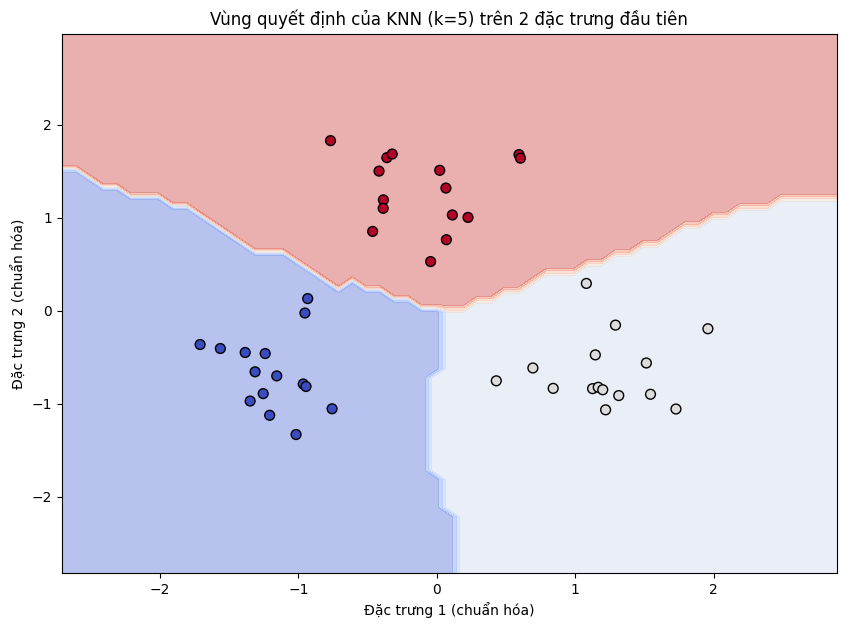

In [24]:
X_train_2d = X_train[:, :2]
X_test_2d = X_test[:, :2]

# Huấn luyện lại KNN với dữ liệu 2D
knn_model_2d = KNNClassifier(k=5)
knn_model_2d.fit(X_train_2d, y_train) # y_train vẫn giữ nguyên
y_pred_knn_2d = knn_model_2d.predict(X_test_2d)

# Tạo lưới điểm để vẽ vùng quyết định cho KNN
x_min, x_max = X_scaled[:, 0].min() - 1, X_scaled[:, 0].max() + 1
y_min, y_max = X_scaled[:, 1].min() - 1, X_scaled[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Dự đoán trên lưới điểm (chỉ dùng 2 đặc trưng)
Z_knn = knn_model_2d.predict(np.c_[xx.ravel(), yy.ravel()])
Z_knn = Z_knn.reshape(xx.shape)

plt.figure(figsize=(10, 7))
plt.contourf(xx, yy, Z_knn, alpha=0.4, cmap=plt.cm.coolwarm)
plt.scatter(X_test_2d[:, 0], X_test_2d[:, 1], c=y_test, s=50, edgecolor='k', cmap=plt.cm.coolwarm)
plt.title("Vùng quyết định của KNN (k=5) trên 2 đặc trưng đầu tiên")
plt.xlabel("Đặc trưng 1 (chuẩn hóa)")
plt.ylabel("Đặc trưng 2 (chuẩn hóa)")
plt.show()

## 7. Nhận xét và Kết luận

-   **KNN:**
    * Đã xây dựng thành công thuật toán KNN từ đầu.
    * Độ chính xác phụ thuộc vào việc chọn $k$ và thước đo khoảng cách.
    * Dữ liệu cần được chuẩn hóa để đảm bảo các đặc trưng có đóng góp tương đương.

-   **One-vs-Rest (OvR) với Perceptron:**
    * Đã xây dựng thành công chiến lược OvR, sử dụng Perceptron làm bộ phân loại nhị phân cơ sở.
    * Mỗi lớp được huấn luyện một Perceptron để phân biệt với tất cả các lớp còn lại.
    * Dự đoán dựa trên bộ phân loại nào cho "điểm số" tự tin nhất.

-   **One-vs-One (OvO) với Perceptron:**
    * Đã xây dựng thành công chiến lược OvO.
    * Huấn luyện một Perceptron cho mỗi cặp lớp.
    * Dự đoán dựa trên "bỏ phiếu" từ các bộ phân loại nhị phân.

-   **So sánh chung:**
    * Cả ba phương pháp đều có thể giải quyết bài toán phân loại đa lớp.
    * KNN là thuật toán đơn giản và trực quan. OvR và OvO là các kỹ thuật meta-classifier, tận dụng các bộ phân loại nhị phân.
    * Hiệu suất của OvR và OvO phụ thuộc nhiều vào hiệu suất của bộ phân loại nhị phân cơ sở (ở đây là Perceptron). Do Perceptron chỉ hoạt động tốt với dữ liệu phân tách tuyến tính, nên nếu các bài toán nhị phân con không phân tách tuyến tính, kết quả của OvR/OvO có thể không cao.
    * Trong thực tế, với các bộ phân loại nhị phân mạnh mẽ hơn (như SVM có kernel), OvR và OvO có thể cho kết quả rất tốt.

-   **Lưu ý về Dataset:** Kết quả độ chính xác thu được ở đây là trên bộ dữ liệu mẫu được tạo ra. Khi nhóm thay thế bằng bộ dữ liệu tự thu thập, kết quả có thể sẽ khác. Điều quan trọng là hiểu cách các thuật toán hoạt động và được triển khai.
